# FINANCE 384 --- Lecture 2

## Pooled Data and Pooled Regressions

This notebook is the computational companion to Lecture 2. It works through four
technical ideas from the lecture, using one stock-month panel throughout:

1. **building the target** --- turning an unbalanced panel into a data set that predicts
   month $t+1$ from month $t$, without ever inventing a return;
2. **one stock vs the whole panel** --- why pooling sharpens the estimate, and by how much;
3. **two routes to the same estimates** --- a one-step linear-algebra solve and gradient
   descent;
4. **imputing missing characteristics** without using future information.

The benchmark model is the one from the lecture slides:

$$r^e_{i,t+1} = \alpha + \beta_1\,\text{Size}_{i,t} + \beta_2\,\text{BM}_{i,t}
+ \beta_3\,\text{Mom}_{i,t} + \varepsilon_{i,t+1}$$

One row is one stock $i$ observed at the end of decision month $t$. Every feature is
known at $t$; the target is realised over month $t+1$.


## Learning objectives

After working through this notebook you should be able to:

1. describe an unbalanced stock-month panel and check it before modelling;
2. build a $t+1$ target with an explicit calendar join, so a gap in a stock's coverage
   can never turn into a fabricated observation;
3. compare a single-stock regression with a pooled regression, and say *how much*
   precision pooling buys;
4. explain why clustering by month changes that answer;
5. fit the same OLS by a one-step solve and by gradient descent, and check that they
   agree;
6. impute a missing characteristic from the same-month cross-section, and say why that
   rule contains no look-ahead.


## 1. Imports and settings

**Two libraries, one estimator.** `scikit-learn` fits and predicts throughout.
`statsmodels` appears only where we need standard errors, $t$-statistics, confidence
intervals, or clustering --- none of which `scikit-learn` reports. Both compute the same
least-squares estimator, which Section 6 verifies.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error

pd.set_option("display.precision", 5)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

# One seed for the whole notebook so every result is reproducible
SEED = 384

FEATURES = ["size", "bm", "mom12_2"]   # characteristics known at the end of month t


## 2. The data

`FINANCE384_topic1_lecture_panel.csv` is a monthly panel of S&P 500 stocks built from
CRSP and Compustat: 141,886 rows, 1,030 stocks, January 2000 to December 2024, and
roughly 470 stocks in any one month. One row is one stock-month $(i, t)$ --- stock $i$
observed at the end of month $t$. The panel is **unbalanced**: index membership changes,
so stocks enter and leave and no stock is present for all 300 months.

| Column | Meaning | Timing |
|---|---|---|
| `permno` | CRSP stock identifier --- the unit $i$ | identifier |
| `date` | last trading day of decision month $t$ | identifier |
| `ticker`, `comnam`, `exchcd`, `siccd`, `gvkey` | security and firm labels | identifier |
| `industry`, `ff49_code`, `ff49_name` | industry classification | known at $t$ |
| `size` | log market capitalisation | known at $t$ |
| `bm` | book equity (6-month availability lag) / market capitalisation | known at $t$ |
| `mom12_2` | cumulative return over months $t-11$ to $t-1$, skipping month $t$ | known at $t$ |
| `down_market` | 1 if the trailing 12-month market excess return is negative | known at $t$ |
| `ret_excess_t` | delisting-adjusted return in excess of the risk-free rate | earned over $t$ |

**What `ret_excess_t` measures.** It is the return from the end of month $t-1$ to the end
of month $t$: earned *over* month $t$, and therefore known *at* the end of month $t$,
which is the decision date. It is an outcome for month $t$, not a forecast of month
$t+1$ --- the file supplies no prediction target at all. Section 4 builds one.

*Running in Colab:* upload the CSV into the same folder as the notebook, then run the
cell below unchanged.


In [2]:
panel = pd.read_csv("FINANCE384_topic1_lecture_panel.csv", parse_dates=["date"])

print(f"Rows           : {len(panel):,}")
print(f"Distinct stocks: {panel['permno'].nunique():,}")
print(f"Months         : {panel['date'].nunique():,} "
      f"({panel['date'].min():%Y-%m} to {panel['date'].max():%Y-%m})")
panel.head()


Rows           : 141,886
Distinct stocks: 1,030
Months         : 300 (2000-01 to 2024-12)


,date,permno,ticker,comnam,exchcd,siccd,industry,ff49_code,ff49_name,gvkey,size,bm,mom12_2,down_market,ret_excess_t
0,2000-01-31,10078,SUNW,SUN MICROSYSTEMS INC,3,3571,Manufacturing,34,BusSv,12136,25.53255,0.03923,1.77181,0,0.01043
1,2000-02-29,10078,SUNW,SUN MICROSYSTEMS INC,3,3571,Manufacturing,34,BusSv,12136,25.72517,0.03236,2.22929,0,0.20811
2,2000-03-31,10078,SUNW,SUN MICROSYSTEMS INC,3,3571,Manufacturing,34,BusSv,12136,25.72487,0.03237,2.04648,0,-0.02094
3,2000-04-28,10078,SUNW,SUN MICROSYSTEMS INC,3,3571,Manufacturing,34,BusSv,12136,25.70724,0.03295,2.13323,0,-0.02344
4,2000-05-31,10078,SUNW,SUN MICROSYSTEMS INC,3,3571,Manufacturing,34,BusSv,12136,25.52506,0.03953,2.07741,0,-0.17155


## 3. Validate before modelling

Four checks worth doing every time: one row per stock-month, confirmation that the panel
really is unbalanced, no missing values in the columns we model with, and feature values
that look sensible.


In [3]:
# Check 1: is (permno, date) a unique key? If not, every groupby and merge below is unreliable.
print(f"Duplicate (permno, date) rows: {panel.duplicated(['permno', 'date']).sum()}")

# Check 2: how many stocks are in each month, and how many months does a stock survive?
stocks_per_month = panel.groupby("date")["permno"].nunique()
months_per_stock = panel.groupby("permno")["date"].nunique()
print(f"Stocks per month : {stocks_per_month.min()} to {stocks_per_month.max()} "
      f"(mean {stocks_per_month.mean():.0f})")
print(f"Months per stock : {months_per_stock.min()} to {months_per_stock.max()} "
      f"(median {months_per_stock.median():.0f})   -> unbalanced")

# Check 3: missing values in the columns we model with
print("\nMissing values:")
print(panel[FEATURES + ["ret_excess_t"]].isna().sum())

# Check 4: do the feature distributions look reasonable?
print("\nFeature summary:")
panel[FEATURES + ["ret_excess_t"]].describe().loc[["mean", "std", "min", "max"]]


Duplicate (permno, date) rows: 0
Stocks per month : 450 to 488 (mean 473)
Months per stock : 1 to 300 (median 108)   -> unbalanced

Missing values:
size            0
bm              0
mom12_2         0
ret_excess_t    0
dtype: int64

Feature summary:


,size,bm,mom12_2,ret_excess_t
mean,23.52397,0.50096,0.10589,0.00790
std,1.18870,0.61459,0.34919,0.09918
min,18.57262,0.00005,-0.98957,-0.97963
max,28.96215,84.79661,10.43800,2.62663


## 4. Building the target

**Panel data, pooled regression.** The data set is an *unbalanced panel*: the same stocks
observed repeatedly over time, entering and leaving as index membership changes.
*Pooled* describes what we do to it --- stack every stock-month into one long data frame
and fit one common line --- not the structure of the data itself. Appendix B of the
lecture relaxes that common line with fixed effects.

### 4.1 Sort first

Every lag, rolling window, and cumulative sum walks down the rows in order, so sorting by
stock and then date is what makes those operations mean what they say. The target below
is built with a join and does not depend on row order, but everything else in a panel
workflow does.


In [4]:
panel = panel.sort_values(["permno", "date"]).reset_index(drop=True)
panel[["permno", "date", "size", "bm", "mom12_2", "ret_excess_t"]].head()


,permno,date,size,bm,mom12_2,ret_excess_t
0,10078,2000-01-31,25.53255,0.03923,1.77181,0.01043
1,10078,2000-02-29,25.72517,0.03236,2.22929,0.20811
2,10078,2000-03-31,25.72487,0.03237,2.04648,-0.02094
3,10078,2000-04-28,25.70724,0.03295,2.13323,-0.02344
4,10078,2000-05-31,25.52506,0.03953,2.07741,-0.17155


### 4.2 Attaching next month's return

We want the return earned over month $t+1$ sitting on month $t$'s row:

$$\text{target}_{i,t} = r^e_{i,t+1}.$$

The obvious line is `panel.groupby("permno")["ret_excess_t"].shift(-1)`, which takes the
value from the *row below within the same stock*. That is the right value only if the row
below is the *next calendar month*, and in an unbalanced panel it often is not: a stock
can drop out of the index and rejoin two years later, and `shift(-1)` will happily return
that later month's number with no error and no warning.

Rather than shifting by position and then repairing the damage, join by calendar. Take
each stock-month's return, relabel it with the decision month it belongs to
($t = $ its own month minus one), and merge it back on `(permno, month)`. A month that
does not exist simply fails to match, and the target is `NaN` --- which is exactly what
it should be.

Two habits make this safe:

- `date.dt.to_period("M")` turns a month-end date into a calendar month, so `- 1` is
  month arithmetic: it moves a return to the month whose forecast it settles, whatever
  row that happens to be;
- `validate="one_to_one"` makes pandas raise if either side has duplicate keys, rather
  than silently duplicating rows.


In [5]:
TARGET = "target_ret_excess_tp1"       # r^e_{i,t+1}: the thing we are trying to predict

panel["month"] = panel["date"].dt.to_period("M")

# Each stock-month's realised return, relabelled with the decision month it settles
next_month_return = (
    panel[["permno", "month", "ret_excess_t"]]
    .rename(columns={"ret_excess_t": TARGET})
    .assign(month=lambda df: df["month"] - 1)
)

panel = panel.merge(next_month_return, on=["permno", "month"], how="left",
                    validate="one_to_one")

# Where no t+1 return exists, is it the stock's final month or a gap in its coverage?
final_month = panel.groupby("permno")["month"].transform("max").eq(panel["month"])
no_target = panel[TARGET].isna()

print(f"Rows                 : {len(panel):,}")
print(f"Usable targets       : {panel[TARGET].notna().sum():,}")
print(f"No month t+1 in data : {no_target.sum():,}")
print(f"  ... stock's last month: {(no_target & final_month).sum():,}")
print(f"  ... gap in coverage   : {(no_target & ~final_month).sum():,}")

panel.loc[:4, ["permno", "month", "ret_excess_t", TARGET]]


Rows                 : 141,886
Usable targets       : 140,786
No month t+1 in data : 1,100
  ... stock's last month: 1,030
  ... gap in coverage   : 70


,permno,month,ret_excess_t,target_ret_excess_tp1
0,10078,2000-01,0.01043,0.20811
1,10078,2000-02,0.20811,-0.02094
2,10078,2000-03,-0.02094,-0.02344
3,10078,2000-04,-0.02344,-0.17155
4,10078,2000-05,-0.17155,0.18279


Those 70 coverage gaps are the rows a positional `shift(-1)` would have filled with a
return from much later: the gaps in this panel run from 12 months to 14 years. They are
a small share of the rows, and they would never have announced themselves.

### 4.3 Two samples from one panel

Both samples below use the same columns. They differ only in how many stocks they keep.

- **`stock_months`** --- every stock, every month, one row per stock-month.
- **`one_stock`** --- a single firm's monthly time series, one row per month.


In [6]:
# ret_excess_t has done its job. It is a legitimate time-t predictor of a t+1 target, but
# the benchmark specification is size, value and momentum only -- keeping it in the frame
# invites it into a feature matrix and quietly changes the model being estimated.
stock_months = (
    panel.dropna(subset=FEATURES + [TARGET])
         .drop(columns=["ret_excess_t"])
         .reset_index(drop=True)
)

TICKER = "JNJ"
one_stock = stock_months[stock_months["ticker"] == TICKER].copy()

print(f"stock_months: {len(stock_months):>7,} rows  x  "
      f"{stock_months['permno'].nunique():,} stocks")
print(f"one_stock   : {len(one_stock):>7,} rows  x  1 stock ({TICKER})")


stock_months: 140,786 rows  x  1,029 stocks
one_stock   :     299 rows  x  1 stock (JNJ)


## 5. One stock vs the whole panel

### 5.1 The regression on a single stock

Twenty-five years of monthly data for one large, well-known firm. That feels like a lot.


In [7]:
def fit_benchmark(data, features=FEATURES):
    """Fit the benchmark regression on `data` with scikit-learn."""
    return LinearRegression().fit(data[features], data[TARGET])


def coefficients(model):
    """Label a fitted model's intercept and slopes."""
    return pd.Series(np.r_[model.intercept_, model.coef_], index=["intercept"] + FEATURES)


single = fit_benchmark(one_stock)
print(f"{TICKER}: {len(one_stock)} monthly observations\n")
coefficients(single).round(4)


JNJ: 299 monthly observations



intercept    0.1256
size        -0.0049
bm           0.0649
mom12_2     -0.0650
dtype: float64

Three numbers, and no way to tell whether any of them is signal. For that we need
standard errors, which `scikit-learn` does not report --- so this is where `statsmodels`
earns its keep. It is the same estimator: the `coef` column below reproduces the
coefficients above.


In [8]:
single_inference = sm.OLS(
    one_stock[TARGET], sm.add_constant(one_stock[FEATURES])
).fit()

print(f"R-squared = {single_inference.rsquared:.4f}\n")
pd.DataFrame({
    "coef": single_inference.params,
    "std err": single_inference.bse,
    "t": single_inference.tvalues,
    "CI low": single_inference.conf_int()[0],
    "CI high": single_inference.conf_int()[1],
}).round(4)


R-squared = 0.0421



,coef,std err,t,CI low,CI high
const,0.1256,0.1814,0.6924,-0.2314,0.4826
size,-0.0049,0.0069,-0.7079,-0.0185,0.0087
bm,0.0649,0.0455,1.4268,-0.0246,0.1544
mom12_2,-0.0650,0.0217,-2.9929,-0.1078,-0.0223


Look at the confidence interval on `bm`. It spans zero comfortably: on this stock alone
we cannot say whether the value effect is positive, negative, or absent. The point
estimate is not wrong, it is simply drowned in the noise of one firm's monthly returns.

Now look at `mom12_2`, which comes out large, negative, and apparently significant. Hold
on to that number --- the pooled regression in the next cell will say it is noise. A
single stock can manufacture a convincing-looking result out of nothing, which is the
real reason one firm's history cannot settle an asset-pricing question.

### 5.2 The same regression, pooled across every stock


In [9]:
pooled = fit_benchmark(stock_months)

pooled_design = sm.add_constant(stock_months[FEATURES])
pooled_inference = sm.OLS(stock_months[TARGET], pooled_design).fit()

# Standard errors clustered by month: all stocks in a month share market-wide news,
# so their errors are correlated and the textbook formula overstates precision.
pooled_clustered = sm.OLS(stock_months[TARGET], pooled_design).fit(
    cov_type="cluster", cov_kwds={"groups": stock_months["date"]}
)

print(f"one stock : {len(one_stock):,} rows")
print(f"pooled    : {len(stock_months):,} rows\n")
pd.DataFrame({
    "one stock: coef": coefficients(single).to_numpy(),
    "one stock: t": single_inference.tvalues.to_numpy(),
    "pooled: coef": coefficients(pooled).to_numpy(),
    "pooled: t": pooled_inference.tvalues.to_numpy(),
    "pooled: t (clustered by month)": pooled_clustered.tvalues.to_numpy(),
}, index=["intercept"] + FEATURES).round(4)


one stock : 299 rows
pooled    : 140,786 rows



,one stock: coef,one stock: t,pooled: coef,pooled: t,pooled: t (clustered by month)
intercept,0.1256,0.6924,0.0379,6.9290,1.2595
size,-0.0049,-0.7079,-0.0015,-6.4977,-1.2012
bm,0.0649,1.4268,0.0107,23.1036,2.7771
mom12_2,-0.0650,-2.9929,0.0010,1.2799,0.1487


Pooling changes both answers that mattered. The value slope is now measured precisely
enough to be distinguishable from zero, and the momentum slope --- the one that looked
significant on JNJ alone --- collapses to nothing.

The last two columns are the same coefficients with two different accounts of how
certain we are about them. Treating every row as an independent draw gives the value
slope a $t$ of about 23; allowing stocks in the same month to share market-wide shocks
cuts it to about 2.8. There are 140,786 rows here, but nothing like 140,786 independent
observations, and the honest column is the clustered one.

### 5.3 How much precision does pooling buy?

Fit the *same* regression separately on every stock with at least 60 months of data, and
compare the spread of those estimates with the precision of the pooled one.


In [10]:
BM = FEATURES.index("bm")
MIN_MONTHS = 60

months_available = stock_months.groupby("permno").size()
long_enough = months_available[months_available >= MIN_MONTHS].index

per_stock_bm = pd.Series({
    permno: fit_benchmark(stock_data).coef_[BM]
    for permno, stock_data in stock_months[stock_months["permno"].isin(long_enough)].groupby("permno")
})

pooled_bm = pooled.coef_[BM]
ci_low, ci_high = pooled_clustered.conf_int().loc["bm"]
spread_low, spread_high = per_stock_bm.quantile([0.05, 0.95])

print(f"Stocks fitted individually : {len(per_stock_bm):,} (>= {MIN_MONTHS} months each)")
print(f"Mean of the slopes         : {per_stock_bm.mean():.4f}")
print(f"Std dev across stocks      : {per_stock_bm.std():.4f}")
print(f"Share with a positive slope: {100 * (per_stock_bm > 0).mean():.0f}%")
print(f"Middle 90% of the slopes   : [{spread_low:.4f}, {spread_high:.4f}]")
print(f"\nPooled estimate            : {pooled_bm:.4f}")
print(f"Clustered standard error   : {pooled_clustered.bse['bm']:.4f}")
print(f"Pooled 95% CI (clustered)  : [{ci_low:.4f}, {ci_high:.4f}]")
print(f"\nDispersion across stocks / pooled standard error : "
      f"{per_stock_bm.std() / pooled_clustered.bse['bm']:.0f}x")
print(f"Middle-90% range / width of the pooled 95% CI    : "
      f"{(spread_high - spread_low) / (ci_high - ci_low):.0f}x")


Stocks fitted individually : 736 (>= 60 months each)
Mean of the slopes         : 0.0977
Std dev across stocks      : 0.3233
Share with a positive slope: 73%
Middle 90% of the slopes   : [-0.1700, 0.5370]

Pooled estimate            : 0.0107
Clustered standard error   : 0.0039
Pooled 95% CI (clustered)  : [0.0031, 0.0182]

Dispersion across stocks / pooled standard error : 84x
Middle-90% range / width of the pooled 95% CI    : 47x


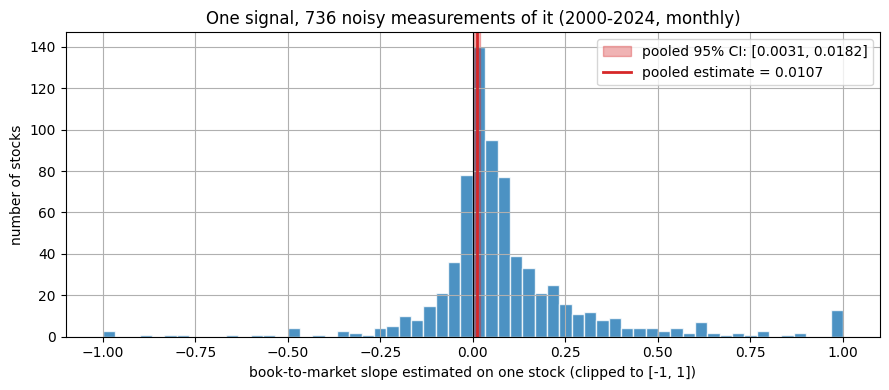

In [11]:
fig, ax = plt.subplots()
ax.hist(per_stock_bm.clip(-1, 1), bins=60, alpha=0.8, edgecolor="white")
ax.axvspan(ci_low, ci_high, color="C3", alpha=0.35,
           label=f"pooled 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
ax.axvline(pooled_bm, color="C3", lw=2, label=f"pooled estimate = {pooled_bm:.4f}")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("book-to-market slope estimated on one stock (clipped to [-1, 1])")
ax.set_ylabel("number of stocks")
ax.set_title(f"One signal, {len(per_stock_bm)} noisy measurements of it (2000-2024, monthly)")
ax.legend()
plt.tight_layout()
plt.show()


Each bar is one stock's answer to the same question, and they scatter from strongly
negative to strongly positive: 27% of stocks report a negative value slope. The pooled
answer sits in the middle of the pile, and the numbers above put the gain in precision on
a scale:

- the dispersion of the single-stock estimates is about **84 times** the standard error
  of the pooled estimate;
- the middle 90% of them spans a range about **47 times wider** than the pooled 95%
  confidence interval --- the shaded band, which is narrower than the line drawn on top
  of it.

That is the whole idea of pooling. The common component is the part that survives
averaging across stocks; the stock-specific noise is the part that cancels.

One caveat on the first number: the spread across stocks mixes estimation noise with any
genuine differences between firms, so it is an upper bound on how imprecise a single
stock's estimate is. Pooling assumes those genuine differences are small enough to ignore
--- which is precisely the restriction the lecture's *Why Pool --- and What It Costs*
slide asks you to defend.


## 6. Two routes to the same estimates

Pooled OLS minimises one convex loss,

$$L(\beta) = \frac{1}{n}\lVert y - X\beta \rVert^2 ,$$

and there are two ways to reach the minimum.

- **One step.** Solve the normal equations $X'X\beta = X'y$ directly. `statsmodels` and
  `scikit-learn`'s `LinearRegression` both take this route. (Both use a matrix
  factorisation rather than forming $(X'X)^{-1}$ explicitly, which is faster and
  numerically safer, but the $\widehat\beta$ is the same.)
- **Many steps.** Start from a guess and walk downhill, using a block of rows at a time.
  `scikit-learn`'s `SGDRegressor` takes this route.

On three features and 140,786 rows the one-step solve is instant. The iterative route is
the one that survives when $X'X$ no longer fits in memory --- the argument of the lecture
slide *How Big Does the Cross-Section Get?*

### 6.1 The one-step route


In [12]:
statsmodels_ols = sm.OLS(stock_months[TARGET], pooled_design).fit()

one_step = pd.DataFrame({
    "statsmodels (normal equations)": statsmodels_ols.params.to_numpy(),
    "sklearn LinearRegression": coefficients(pooled).to_numpy(),
}, index=["intercept"] + FEATURES)

print(f"Largest difference: "
      f"{np.abs(one_step.iloc[:, 0] - one_step.iloc[:, 1]).max():.2e}\n")
one_step.round(6)


Largest difference: 7.22e-16



,statsmodels (normal equations),sklearn LinearRegression
intercept,0.03794,0.03794
size,-0.00150,-0.00150
bm,0.01070,0.01070
mom12_2,0.00100,0.00100


### 6.2 The iterative route

`SGDRegressor` walks downhill instead of solving. `partial_fit` makes one pass over
whatever rows it is handed and then stops, so feeding it the panel one block at a time is
a working model of the situation the lecture cares about: the coefficients improve from a
block of rows, and the full design matrix is never assembled.

Two settings are doing real work:

- `learning_rate="constant"` with `eta0` fixes the step size, which makes choosing it a
  visible decision rather than a hidden default --- Section 6.3 makes that choice;
- `average=True` averages the coefficients along the path, the standard remedy for the
  jitter drawn in the lecture's *Three Descent Paths* figure.


In [13]:
BLOCK_ROWS = 4096      # rows in memory at any one time
EPOCHS = 200           # full passes over the panel

X = stock_months[FEATURES].to_numpy()
y = stock_months[TARGET].to_numpy()


def descend(learning_rate, epochs=EPOCHS, block=BLOCK_ROWS):
    """Fit the benchmark by gradient descent, streaming the panel one block at a time."""
    model = SGDRegressor(
        loss="squared_error",       # ordinary least squares
        penalty=None,               # no shrinkage yet -- that is Lecture 3
        learning_rate="constant",
        eta0=learning_rate,
        average=True,
        random_state=SEED,
    )
    rng = np.random.default_rng(SEED)

    mse_by_epoch = []
    for _ in range(epochs):
        shuffled = rng.permutation(len(X))
        for start in range(0, len(X), block):
            rows = shuffled[start:start + block]
            model.partial_fit(X[rows], y[rows])     # improve the fit from this block only
        mse_by_epoch.append(mean_squared_error(y, model.predict(X)))
    return model, np.array(mse_by_epoch)


gradient_descent, _ = descend(0.002)

three_routes = one_step.assign(**{
    "sklearn SGDRegressor": np.r_[gradient_descent.intercept_[0], gradient_descent.coef_]
})

print(f"Blocks per epoch: {int(np.ceil(len(X) / BLOCK_ROWS))}")
print(f"Largest gap to the one-step estimates: "
      f"{np.abs(three_routes.iloc[:, 2] - three_routes.iloc[:, 0]).max():.2e}\n")
three_routes.round(6)


Blocks per epoch: 35
Largest gap to the one-step estimates: 2.37e-05



,statsmodels (normal equations),sklearn LinearRegression,sklearn SGDRegressor
intercept,0.03794,0.03794,0.03794
size,-0.00150,-0.00150,-0.00150
bm,0.01070,0.01070,0.01069
mom12_2,0.00100,0.00100,0.00103


All three routes land in the same place. The two one-step routes are the same calculation
done by two libraries, so they match to machine precision; gradient descent stops about
$2 \times 10^{-5}$ short, having never formed $X'X$ and never held more than 4,096 rows
at once. That residual gap is descent noise --- negligible against the size and value
slopes, but about 2% of the momentum slope, which is the reminder that an iterative
solver returns an approximation and you have to decide whether it is close enough.

On this panel that is a bad trade --- the one-step solve is instant and exact. It becomes
the only route available once the design matrix outgrows memory, and it is how the neural
networks of Lectures 5 and 6 are fitted, where no closed form exists at all.

### 6.3 Choosing the learning rate

The step size is the one thing gradient descent cannot work out for itself.


eta = 0.005    gap to the minimum after 40 epochs: 3.52e+19


eta = 0.002    gap to the minimum after 40 epochs: 6.74e-08


eta = 1e-05    gap to the minimum after 40 epochs: 3.00e-06


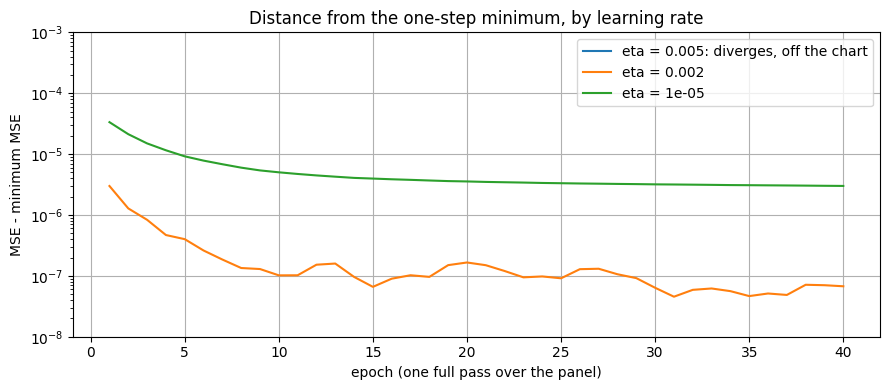

In [14]:
COMPARE_EPOCHS = 40
LEARNING_RATES = [0.005, 0.002, 0.00001]

minimum_mse = mean_squared_error(y, pooled.predict(stock_months[FEATURES]))

TOP_OF_CHART = 1e-3

fig, ax = plt.subplots()
for rate in LEARNING_RATES:
    _, mse_by_epoch = descend(rate, epochs=COMPARE_EPOCHS)
    gap_to_minimum = mse_by_epoch - minimum_mse
    print(f"eta = {rate:<8g} gap to the minimum after {COMPARE_EPOCHS} epochs: "
          f"{gap_to_minimum[-1]:.2e}")

    if gap_to_minimum.max() < TOP_OF_CHART:
        ax.plot(range(1, COMPARE_EPOCHS + 1), gap_to_minimum, label=f"eta = {rate:g}")
    else:   # a diverging path would flatten everything else against the axis
        ax.plot([], [], label=f"eta = {rate:g}: diverges, off the chart")

ax.set_yscale("log")
ax.set_ylim(1e-8, TOP_OF_CHART)
ax.set_xlabel("epoch (one full pass over the panel)")
ax.set_ylabel("MSE - minimum MSE")
ax.set_title("Distance from the one-step minimum, by learning rate")
ax.legend()
plt.tight_layout()
plt.show()


- $\eta = 0.005$ **diverges**: its loss is off the top of the chart --- around $10^{19}$
  after a single epoch --- and more epochs never bring it back.
- $\eta = 0.002$ reaches the one-step minimum within a few epochs and stays there.
- $\eta = 0.00001$ is stable but **crawling**: after 40 epochs it is still further from
  the minimum than $\eta = 0.002$ was after one.

What counts as too large depends on the scale of the features. `size` is around 23 and
`bm` around 0.5, so a step proportional to `size` is roughly fifty times the same step on
`bm`, and one learning rate has to serve both. Standardising the features first removes
that problem, which is why the lecture lists *running gradient descent on unscaled
features* as a common pitfall and why production pipelines almost always scale before
they descend.


## 7. Missing characteristics, and how to fill them

This panel arrives complete, so to demonstrate imputation we first have to *create* the
problem: blank out 15% of the book-to-market values at random.


In [15]:
rng = np.random.default_rng(SEED)

with_gaps = stock_months[["permno", "date", "ff49_name"] + FEATURES + [TARGET]].copy()

# Delete 15% of bm values completely at random
drop_these = rng.random(len(with_gaps)) < 0.15
with_gaps.loc[drop_these, "bm"] = np.nan

print(f"Values deleted: {drop_these.sum():,} of {len(with_gaps):,} "
      f"({100 * drop_these.mean():.1f}%)")


Values deleted: 21,235 of 140,786 (15.1%)


### 7.1 The cost of just dropping the rows

The simplest response is complete-case analysis: keep only rows with no missing values.
It is easy, and it throws away a sixth of the sample.


In [16]:
complete_cases = with_gaps.dropna(subset=["bm"])

print(f"Rows kept   : {len(complete_cases):,}")
print(f"Rows dropped: {len(with_gaps) - len(complete_cases):,} "
      f"({100 * (1 - len(complete_cases) / len(with_gaps)):.1f}%)")

# How many stocks lose at least one month?
stocks_affected = with_gaps.loc[with_gaps["bm"].isna(), "permno"].nunique()
print(f"Stocks with at least one gap: {stocks_affected:,} of {with_gaps['permno'].nunique():,}")


Rows kept   : 119,551
Rows dropped: 21,235 (15.1%)
Stocks with at least one gap: 991 of 1,029


### 7.2 Cross-sectional imputation

Fill each gap with the median of the stocks observed **in the same month**, preferring
the firm's own industry and falling back to the whole market:

$$\widetilde{x}_{i,t} = \text{median}\{x_{j,t} : j \text{ in the same industry-month}\}.$$

Two things make this safe and useful:

- the fill uses only month-$t$ information, so a forecast made at $t$ never sees the
  future;
- we keep a flag recording that the value was missing, because *being missing* can
  itself carry information about a firm.


In [17]:
# Flag first -- missingness can predict risk, coverage, or firm maturity
with_gaps["bm_was_missing"] = with_gaps["bm"].isna().astype(int)

# First choice: median of the same industry, in the same month
industry_median = with_gaps.groupby(["date", "ff49_name"])["bm"].transform("median")

# Fallback: median of the whole market, in the same month
market_median = with_gaps.groupby("date")["bm"].transform("median")

with_gaps["bm_filled"] = with_gaps["bm"].fillna(industry_median).fillna(market_median)

print(f"Still missing after imputation: {with_gaps['bm_filled'].isna().sum()}")
with_gaps.loc[with_gaps["bm_was_missing"] == 1,
              ["date", "ff49_name", "bm", "bm_filled"]].head()


Still missing after imputation: 0


,date,ff49_name,bm,bm_filled
6,2000-07-31,BusSv,NaN,0.11358
15,2001-04-30,BusSv,NaN,0.19292
31,2002-08-30,BusSv,NaN,0.53726
54,2004-07-30,BusSv,NaN,0.29383
67,2005-08-31,BusSv,NaN,0.32742


### 7.3 Does it recover the answer?

Compare three regressions: the full data we started from, complete cases only, and the
imputed sample.


In [18]:
pd.DataFrame({
    "full data": coefficients(fit_benchmark(stock_months)).to_numpy(),
    "complete cases": coefficients(fit_benchmark(complete_cases)).to_numpy(),
    # bm_filled takes bm's place in the specification, so it takes bm's label
    "imputed": coefficients(
        fit_benchmark(with_gaps, ["size", "bm_filled", "mom12_2"])
    ).to_numpy(),
}, index=["intercept"] + FEATURES).round(5)


,full data,complete cases,imputed
intercept,0.03794,0.03511,0.04026
size,-0.00150,-0.00139,-0.00160
bm,0.01070,0.01125,0.01104
mom12_2,0.00100,0.00124,0.00066


All three columns tell the same story here --- and they should, because we deleted the
values *completely at random*. Complete-case analysis is unbiased under that assumption;
it is simply wasteful.

**Real missing data is not random.** Accounting items go missing for small, young,
distressed, and thinly covered firms, so dropping incomplete rows quietly removes a
specific slice of the market and biases whatever you estimate next. That is the case
where imputation stops being a convenience and starts being necessary --- and it is why
the `bm_was_missing` flag is worth keeping.

**The timing rule is what makes this safe.** Everything above is computed inside a single
decision month. Filling with a full-sample average, or with the firm's own later value,
would leak information a forecaster at time $t$ could not have had.


## 8. What to take away

1. **The panel is unbalanced; "pooled" is what we do to it.** Stocks enter and leave, so
   the row below is not reliably month $t+1$.
2. **Build the target by a calendar join, not by row position.** A merge on
   `(permno, month)` cannot invent a return that does not exist. Here 1,100 rows have no
   $t+1$: 1,030 final months plus 70 coverage gaps that a positional shift would have
   filled with the wrong number, silently.
3. **One stock cannot answer an asset-pricing question.** On JNJ the value slope's
   confidence interval straddles zero and the momentum slope looks significant; pooled
   across 1,029 stocks the value slope is distinguishable from zero and momentum is not.
   Single-stock estimates of the same slope are spread about 84 times more widely than
   the pooled estimate's standard error.
4. **Rows are not independent observations.** Clustering by month cuts the value slope's
   $t$-statistic from about 23 to about 2.8, because stocks in the same month share the
   same news.
5. **The one-step solve and gradient descent compute the same estimator.**
   `scikit-learn` and `statsmodels` agree to machine precision, and descent streamed one
   block of rows at a time reaches the same answer to four significant figures --- once
   the learning rate is chosen to suit the scale of the features.
6. **Impute inside the decision month, and keep the flag.** Cross-sectional fills use
   only information available at $t$; a full-sample mean does not.

### Suggested extensions

- Repeat Section 5.3 for `size` and `mom12_2`. Does pooling buy the same precision for
  every characteristic?
- Delete `bm` non-randomly --- say, more often for small stocks --- and repeat Section 7.3.
  How far do the complete-case coefficients move?
- Set `average=False` in Section 6.2 and re-run. How much further from the exact answer
  does gradient descent stop?
